# Problem Set 02: Bank Marketing Prediction Using Logistic Regression

## Objective

The objective of this project is to develop a Logistic Regression model to predict whether a bank customer will subscribe to a term deposit based on customer and banking information.

In [1]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_dir = "/content/drive/MyDrive/prob-2"

print("Files inside prob-2:")
print(os.listdir(base_dir))

Files inside prob-2:
['bank-data (1).zip']


In [4]:
zip_files = glob.glob(base_dir + "/*.zip")

if len(zip_files) > 0:
    zip_path = zip_files[0]

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(base_dir)

    print("Extraction Complete")
else:
    print("No ZIP file found. Dataset may already be extracted.")

Extraction Complete


In [5]:
csv_files = glob.glob(base_dir + "/**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/content/drive/MyDrive/prob-2/bank-data/bank-full.csv


In [6]:
# Prefer bank-full.csv if available
bank_full_files = [f for f in csv_files if os.path.basename(f).lower() == "bank-full.csv"]

if bank_full_files:
    data_path = bank_full_files[0]
else:
    data_path = csv_files[0]

print("Selected dataset:")
print(data_path)

Selected dataset:
/content/drive/MyDrive/prob-2/bank-data/bank-full.csv


In [7]:
df = pd.read_csv(data_path, sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (45211, 17)


In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 45211
Number of Columns: 17


In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print("Target variable distribution:")
print(df['y'].value_counts())

Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


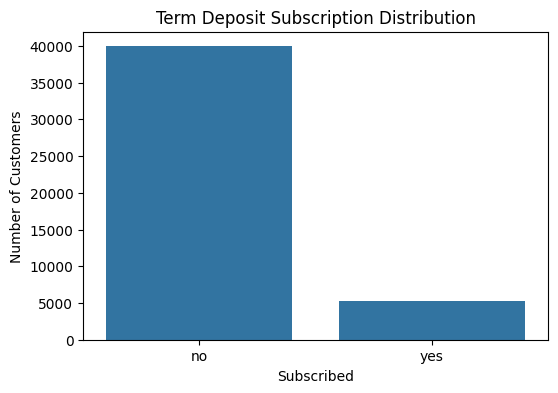

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='y')

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nUnique values:")
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Unique values:

job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']


In [16]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 45211
Rows after removing duplicates: 45211
Duplicates removed: 0


In [17]:
X = df.drop('y', axis=1)
y = df['y']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (45211, 16)
Target shape: (45211,)


In [18]:
y = y.map({'no': 0, 'yes': 1})

print("Encoded target values:")
print(y.value_counts())

Encoded target values:
y
0    39922
1     5289
Name: count, dtype: int64


In [19]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [20]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after One-Hot Encoding:", X_encoded.shape)
print("\nFirst 5 rows:")
display(X_encoded.head())

Shape after One-Hot Encoding: (45211, 42)

First 5 rows:


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 42)
Testing data: (9043, 42)


In [22]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Numerical features normalized successfully!")

Numerical features normalized successfully!


In [23]:
print("Training data mean after scaling:")
print(X_train[numeric_features].mean().round(2))

print("\nTraining data standard deviation after scaling:")
print(X_train[numeric_features].std().round(2))

Training data mean after scaling:
age        -0.0
balance    -0.0
day         0.0
duration   -0.0
campaign    0.0
pdays       0.0
previous   -0.0
dtype: float64

Training data standard deviation after scaling:
age         1.0
balance     1.0
day         1.0
duration    1.0
campaign    1.0
pdays       1.0
previous    1.0
dtype: float64


In [24]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [25]:
logistic_model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [26]:
y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9015813336282207
Accuracy (%): 90.15813336282207


In [28]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6473684210526316
Recall: 0.3487712665406427
F1 Score: 0.4533169533169533


In [29]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No', 'Yes'],
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [30]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7784  201]
 [ 689  369]]


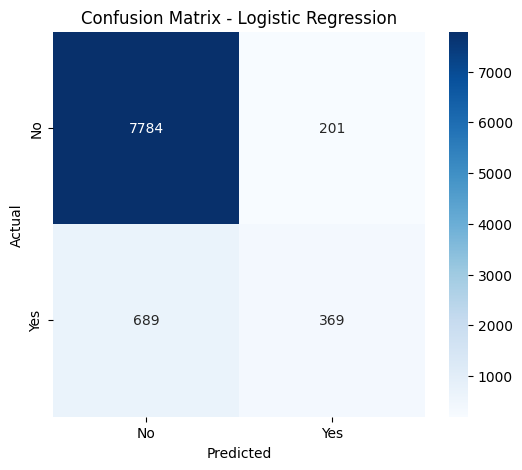

In [31]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

results['Percentage'] = results['Score'] * 100

display(results)

,Metric,Score,Percentage
0,Accuracy,0.901581,90.158133
1,Precision,0.647368,64.736842
2,Recall,0.348771,34.877127
3,F1 Score,0.453317,45.331695


In [33]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

display(coefficients.head(15))

,Feature,Coefficient,Absolute_Coefficient
40,poutcome_success,2.325623,2.325623
27,contact_unknown,-1.595764,1.595764
34,month_mar,1.432003,1.432003
31,month_jan,-1.277590,1.277590
3,duration,1.092146,1.092146
36,month_nov,-0.914143,0.914143
32,month_jul,-0.872532,0.872532
38,month_sep,0.806944,0.806944
37,month_oct,0.802798,0.802798
28,month_aug,-0.764789,0.764789


## Findings

The Logistic Regression model was developed to predict whether a customer would subscribe to a bank term deposit.

The dataset was checked for missing values and duplicate records. The categorical variables were converted into numerical form using One-Hot Encoding. The numerical features were standardized using StandardScaler.

The dataset was divided into training and testing sets using an 80:20 ratio.

### Model Performance

- Accuracy: **90.16%**
- Precision: **64.74%**
- Recall: **34.88%**
- F1 Score: **45.33%**

The model achieved a high overall accuracy of 90.16%. However, the recall for customers who subscribed to a term deposit was 34.88%, indicating that the model missed some customers who actually subscribed.

The confusion matrix was:

```text
[[7784  201]
 [ 689  369]]


## Conclusion

A Logistic Regression model was successfully developed to predict whether a bank customer would subscribe to a term deposit.

The categorical features were converted using One-Hot Encoding, and the numerical features were standardized using StandardScaler. The dataset was divided into training and testing sets using an 80:20 ratio.

The model achieved an accuracy of **90.16%**, precision of **64.74%**, recall of **34.88%**, and an F1 score of **45.33%**.

Although the model achieved high overall accuracy, the recall score shows that the model has difficulty identifying some customers who actually subscribe to a term deposit.

This experiment demonstrates how Logistic Regression can be applied to a real-world binary classification problem using customer and banking information.

The model is intended for academic purposes and should not be considered a standalone banking decision-making system.